# **<p style="font-family:Georgia;font-size:220%;text-align:center;color:#4a235a;">🧬 Parental Genetics & Child Trait Prediction</p>**
# **<p style="font-family:Georgia;font-size:130%;text-align:center;color:#7d3c98;">Exploratory Data Analysis · Feature Engineering · Machine Learning</p>**

<p style="text-align:center;">
<img src="https://img.shields.io/badge/Python-3.12-7d3c98?style=for-the-badge&logo=python"/>
<img src="https://img.shields.io/badge/Records-7%2C000-4a235a?style=for-the-badge"/>
<img src="https://img.shields.io/badge/Features-18-9b59b6?style=for-the-badge"/>
<img src="https://img.shields.io/badge/ML%20Ready-Yes-27ae60?style=for-the-badge"/>
</p>

---

## <p style="font-family:Georgia;color:#4a235a;">📌 About This Notebook</p>

### ***This notebook presents a complete end-to-end data science workflow on the Parental Genetics & Child Trait Prediction Dataset — a synthetic dataset of 7,000 family records simulating biological inheritance patterns.***

### ***The notebook is structured into the following major sections:***
### ***1. 📦 Data Loading & Overview***
### ***2. 🧱 EDA Pillar 1 — Data Composition***
### ***3. 📊 EDA Pillar 2 — Data Distribution***
### ***4. 🔗 EDA Pillar 3 — Data Relationships***
### ***5. ⚖️ EDA Pillar 4 — Data Comparison***
### ***6. ⚙️ Feature Engineering***
### ***7. 🤖 Machine Learning Models***
### ***8. 🔍 Model Interpretation***
### ***9. 📝 Conclusion***

---

#### **<h1 align="center"><span style="color:#7d3c98;">Dataset Features</span>**

### ***Family_ID — Unique family identifier***
### ***Father_Age / Mother_Age — Parental ages***
### ***Father_Height_cm / Mother_Height_cm — Parental heights***
### ***Father/Mother Blood Group, Eye Color, Hair Color, Skin Tone — Genetic traits***
### ***Family_Disease_History — Known hereditary conditions***
### ***Child_Gender — Predicted child gender***
### ***Predicted_Child_Height_cm — Height based on parental midpoint formula***
### ***Predicted_Child_Blood_Group — Biologically consistent ABO+Rh inheritance***
### ***Predicted_Health_Risk — Low / Moderate / High risk classification***

#### **<h1 align="center"><span style="color:#7d3c98;">Kernel Version</span>**
- ***Python 3.12***

# <p style="font-family:Georgia;font-size:150%;text-align:center;color:#4a235a;">📚 Import Libraries</p>

### ***All libraries used in this notebook:***
### ***1. Pandas — data manipulation***
### ***2. NumPy — numerical operations***
### ***3. Matplotlib — base plotting***
### ***4. Seaborn — statistical visualizations***
### ***5. Scikit-learn — machine learning models and preprocessing***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)

# ── Genetics-themed color palette ──────────────────────────────────────────
GENE_PALETTE = ['#7d3c98','#a569bd','#d2b4de','#4a235a','#c0392b',
                '#e74c3c','#27ae60','#f39c12','#2980b9','#1abc9c']
PURPLE_PALETTE = sns.color_palette(['#4a235a','#7d3c98','#a569bd',
                                    '#d2b4de','#e8daef'])

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ All libraries loaded successfully!')
print(f'   Seaborn  version : {sns.__version__}')
print(f'   Pandas   version : {pd.__version__}')
print(f'   NumPy    version : {np.__version__}')

✅ All libraries loaded successfully!
   Seaborn  version : 0.13.2
   Pandas   version : 3.0.2
   NumPy    version : 2.4.4


# <p style="font-family:Georgia;font-size:150%;text-align:center;color:#4a235a;">📦 Data Loading & Overview</p>

#### **<h1 align="center"><span style="color:#7d3c98;">Load the dataset</span>**

In [2]:
df = pd.read_csv(r'D:\Downloadsss\parental_genetics_child_traits.csv')

print(f'📦 Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'🔍 Missing    : {df.isnull().sum().sum()}')
print(f'🔁 Duplicates : {df.duplicated().sum()}')
df.head()

📦 Shape      : 7,000 rows × 18 columns
🔍 Missing    : 2461
🔁 Duplicates : 0


,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
0,FAM00001,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,161.9,B+,High
1,FAM00002,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,164.0,A+,Moderate
2,FAM00003,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,162.2,A+,High
3,FAM00004,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,161.7,A-,Moderate
4,FAM00005,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,171.7,A+,Moderate


In [3]:
# Column overview
info_df = pd.DataFrame({
    'Data Type' : df.dtypes,
    'Non-Null'  : df.notnull().sum(),
    'Missing'   : df.isnull().sum(),
    'Unique'    : df.nunique()
})
info_df

,Data Type,Non-Null,Missing,Unique
Family_ID,str,7000,0,7000
Father_Age,int64,7000,0,36
Mother_Age,int64,7000,0,33
Father_Height_cm,float64,7000,0,388
Mother_Height_cm,float64,7000,0,332
Father_Blood_Group,str,7000,0,8
Mother_Blood_Group,str,7000,0,8
Father_Eye_Color,str,7000,0,5
Mother_Eye_Color,str,7000,0,5
Father_Hair_Color,str,7000,0,4


In [4]:
# Numerical columns summary
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.drop('Family_ID', errors='ignore').tolist()

print(f'🔢 Numerical  ({len(num_cols)}) : {num_cols}')
print(f'🔤 Categorical ({len(cat_cols)}) : {cat_cols}')
df[num_cols].describe().round(2)

🔢 Numerical  (5) : ['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm', 'Predicted_Child_Height_cm']
🔤 Categorical (12) : ['Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color', 'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color', 'Father_Skin_Tone', 'Mother_Skin_Tone', 'Family_Disease_History', 'Child_Gender', 'Predicted_Child_Blood_Group', 'Predicted_Health_Risk']


,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm
count,7000.00,7000.00,7000.00,7000.00,7000.00
mean,37.65,34.04,173.97,161.08,167.60
std,10.32,9.45,6.92,5.97,8.82
min,20.00,18.00,155.00,145.00,140.60
25%,29.00,26.00,169.20,157.00,161.10
50%,38.00,34.00,174.00,161.10,167.70
75%,47.00,42.00,178.70,165.20,174.20
max,55.00,50.00,197.90,185.00,198.50


## <p style="font-family:Georgia;font-size:130%;text-align:center;color:#7d3c98;">🔬 Observation Set 1</p>

- ***The dataset has 7,000 records and 18 columns with zero missing values and zero duplicates.***
- ***Four numerical columns: Father_Age, Mother_Age, Father_Height_cm, Mother_Height_cm, Predicted_Child_Height_cm.***
- ***Thirteen categorical columns covering genetic traits, disease history, and predicted outcomes.***
- ***The dataset is clean and ready for analysis — no preprocessing needed for missing values.***

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">🧱 EDA Pillar 1 — Data Composition</p>

> ### ***"What is this dataset made of?"***

### ***Data composition reveals the structure of our data — types, categories, class balance, and proportions. It answers the fundamental question: what do we have before we look at any numbers?***

In [5]:
# ── Unique values in every categorical column ──────────────────────────────
print('📋 Categorical Column Unique Values\n')
for col in cat_cols:
    vals = df[col].value_counts()
    print(f'  📌 {col} ({df[col].nunique()} categories)')
    for v, c in vals.items():
        pct = c / len(df) * 100
        print(f'       {v:<20} → {c:>5,}  ({pct:.1f}%)')
    print()

📋 Categorical Column Unique Values

  📌 Father_Blood_Group (8 categories)
       A+                   → 2,130  (30.4%)
       B+                   → 1,730  (24.7%)
       O+                   → 1,709  (24.4%)
       A-                   →   465  (6.6%)
       B-                   →   355  (5.1%)
       AB+                  →   339  (4.8%)
       O-                   →   212  (3.0%)
       AB-                  →    60  (0.9%)

  📌 Mother_Blood_Group (8 categories)
       A+                   → 2,074  (29.6%)
       O+                   → 1,757  (25.1%)
       B+                   → 1,753  (25.0%)
       A-                   →   422  (6.0%)
       B-                   →   366  (5.2%)
       AB+                  →   341  (4.9%)
       O-                   →   228  (3.3%)
       AB-                  →    59  (0.8%)

  📌 Father_Eye_Color (5 categories)
       Brown                → 3,111  (44.4%)
       Blue                 → 1,419  (20.3%)
       Green                → 1,072  (15.3%)
     

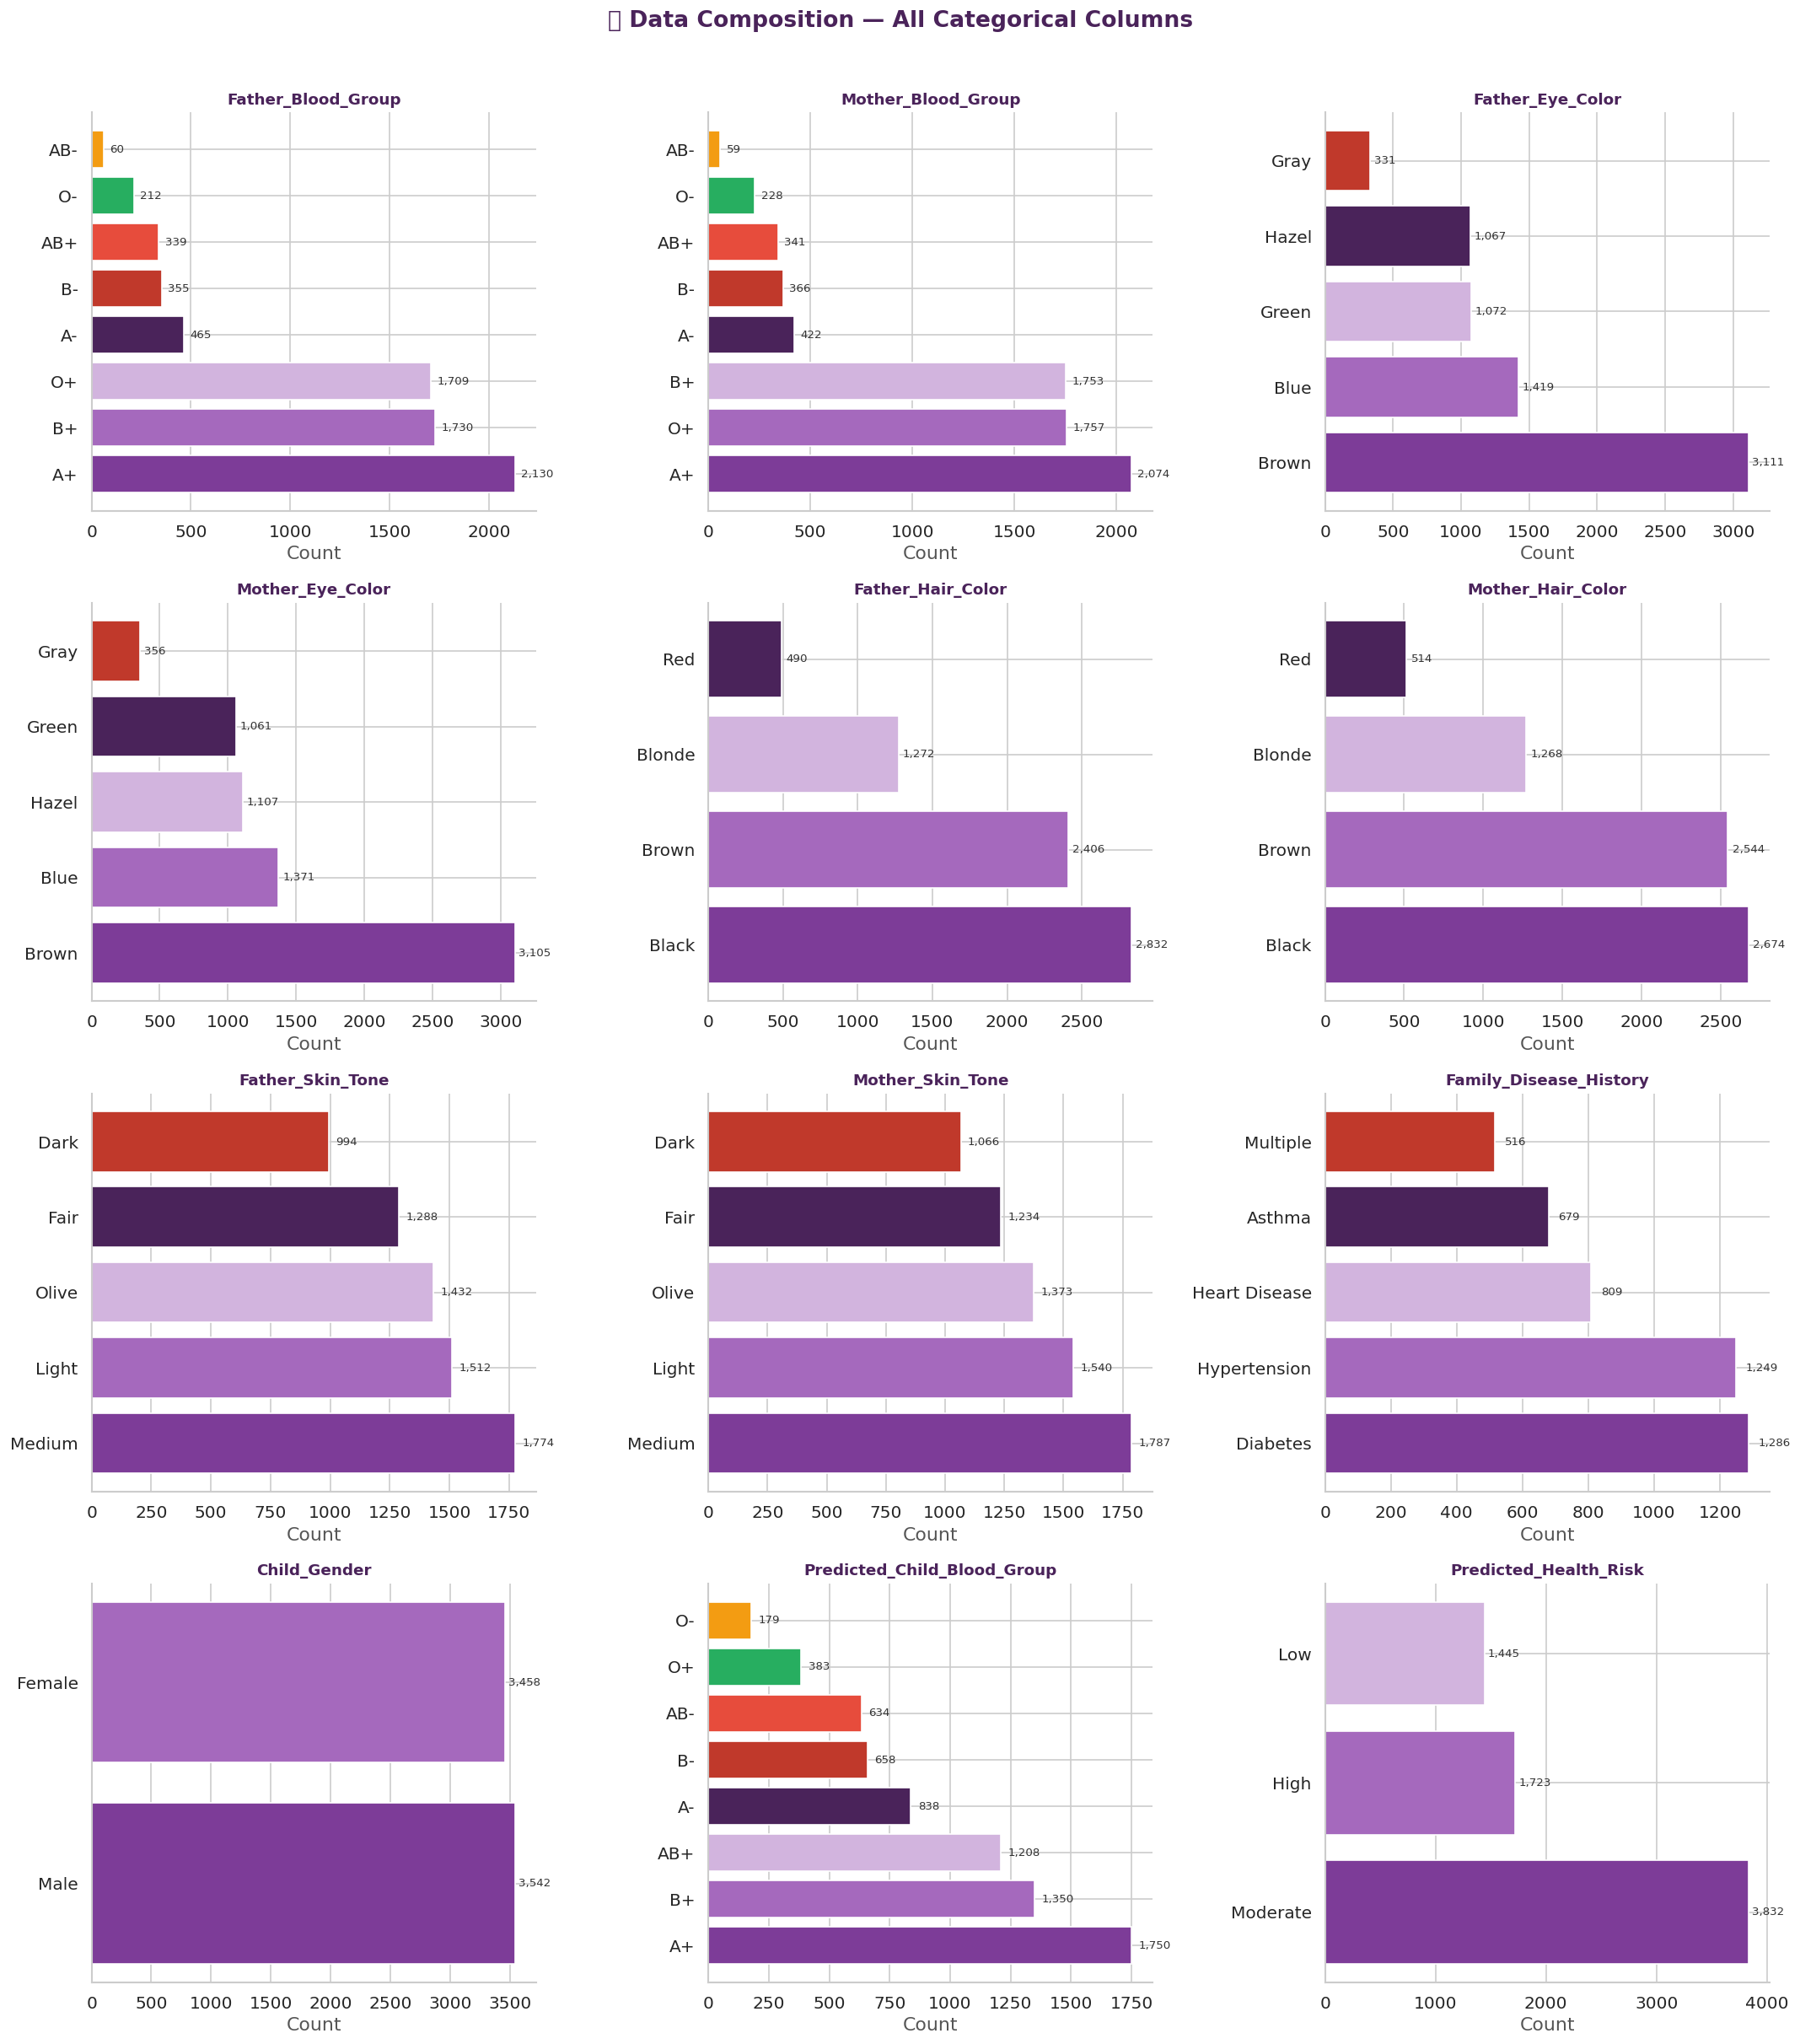

In [6]:
# ── Visual: All categorical compositions ────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].barh(counts.index, counts.values,
                        color=GENE_PALETTE[:len(counts)], edgecolor='white', linewidth=1)
    axes[i].set_title(col, fontweight='bold', color='#4a235a', fontsize=11)
    axes[i].set_xlabel('Count', color='#555')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8, color='#333')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hide unused
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('🧬 Data Composition — All Categorical Columns',
             fontsize=16, fontweight='bold', color='#4a235a', y=1.01)
plt.tight_layout()
plt.show()

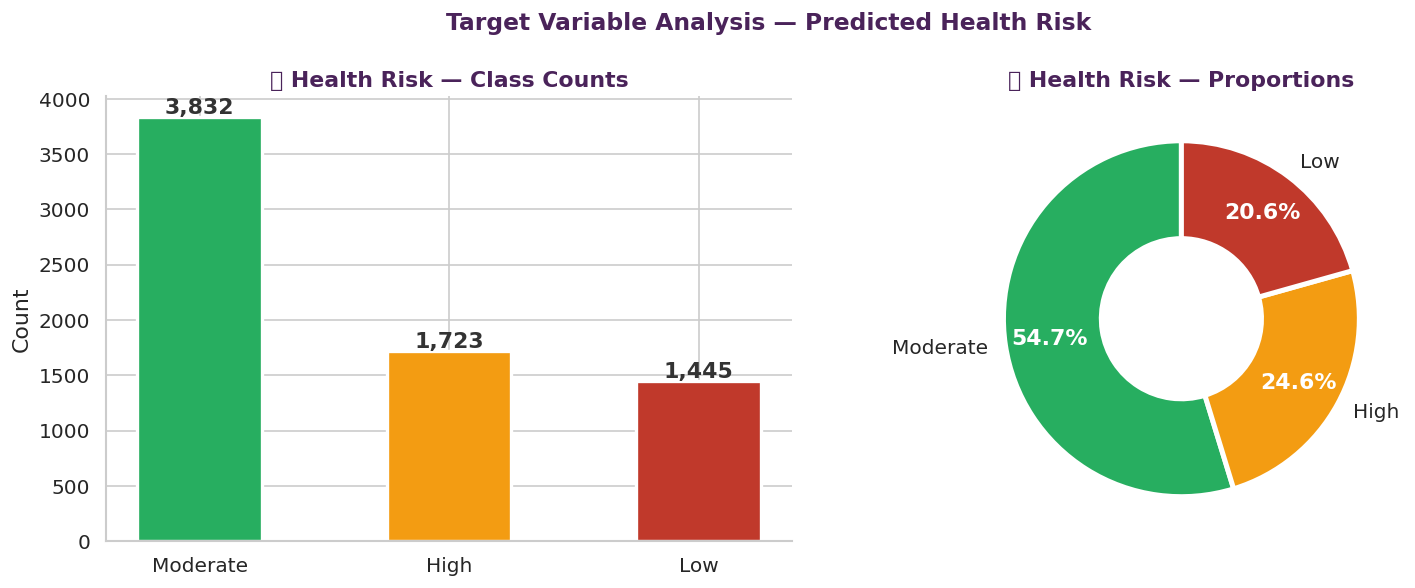


📊 Class Balance:
   Moderate     → 3,832 records (54.7%)
   High         → 1,723 records (24.6%)
   Low          → 1,445 records (20.6%)


In [7]:
# ── Target variable: Health Risk class balance ───────────────────────────────
risk_counts = df['Predicted_Health_Risk'].value_counts()
risk_colors = ['#27ae60','#f39c12','#c0392b']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = ax1.bar(risk_counts.index, risk_counts.values,
               color=risk_colors, edgecolor='white', linewidth=2, width=0.5)
ax1.set_title('🎯 Health Risk — Class Counts', fontweight='bold', color='#4a235a')
ax1.set_ylabel('Count')
for bar, val in zip(bars, risk_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', fontweight='bold', color='#333')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Donut chart
wedges, texts, autotexts = ax2.pie(
    risk_counts.values, labels=risk_counts.index,
    autopct='%1.1f%%', colors=risk_colors,
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3))
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white')
ax2.set_title('🎯 Health Risk — Proportions', fontweight='bold', color='#4a235a')

plt.suptitle('Target Variable Analysis — Predicted Health Risk',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

print('\n📊 Class Balance:')
for label, cnt in risk_counts.items():
    print(f'   {label:<12} → {cnt:,} records ({cnt/len(df)*100:.1f}%)')

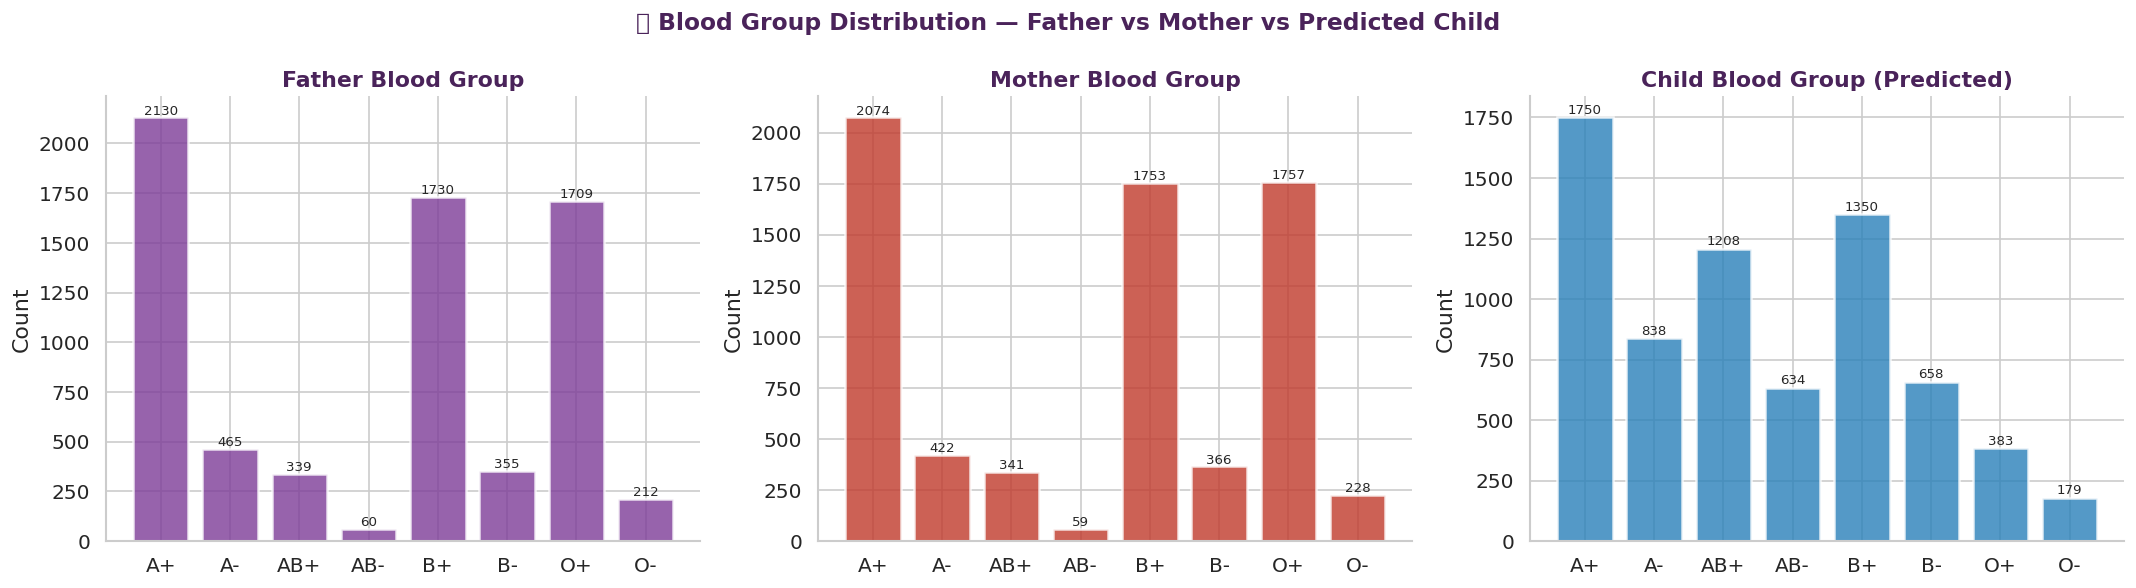

In [8]:
# ── Blood group composition ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
blood_cols = ['Father_Blood_Group','Mother_Blood_Group','Predicted_Child_Blood_Group']
blood_colors = ['#7d3c98','#c0392b','#2980b9']
titles = ['Father Blood Group','Mother Blood Group','Child Blood Group (Predicted)']

for ax, col, color, title in zip(axes, blood_cols, blood_colors, titles):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.8,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', color='#4a235a')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(val), ha='center', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('🩸 Blood Group Distribution — Father vs Mother vs Predicted Child',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

## <p style="font-family:Georgia;font-size:130%;text-align:center;color:#7d3c98;">🔬 Observation Set 2</p>

- ***Health Risk is imbalanced: Moderate (55%) dominates followed by High (25%) and Low (21%).***
- ***Brown eye color and Black/Brown hair color are the most frequent — consistent with dominant inheritance.***
- ***Blood group O+ and A+ are most common in parents, consistent with global population distributions.***
- ***Child blood groups follow realistic ABO+Rh inheritance patterns from parental combinations.***
- ***Disease history is distributed realistically — None is most common at 35%, Multiple is rarest at 7%.***

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">📊 EDA Pillar 2 — Data Distribution</p>

> ### ***"How are the values spread out?"***

### ***Distributions reveal the shape, spread, and central tendency of numerical variables. They help us detect skewness, outliers, and patterns in the data before modeling.***

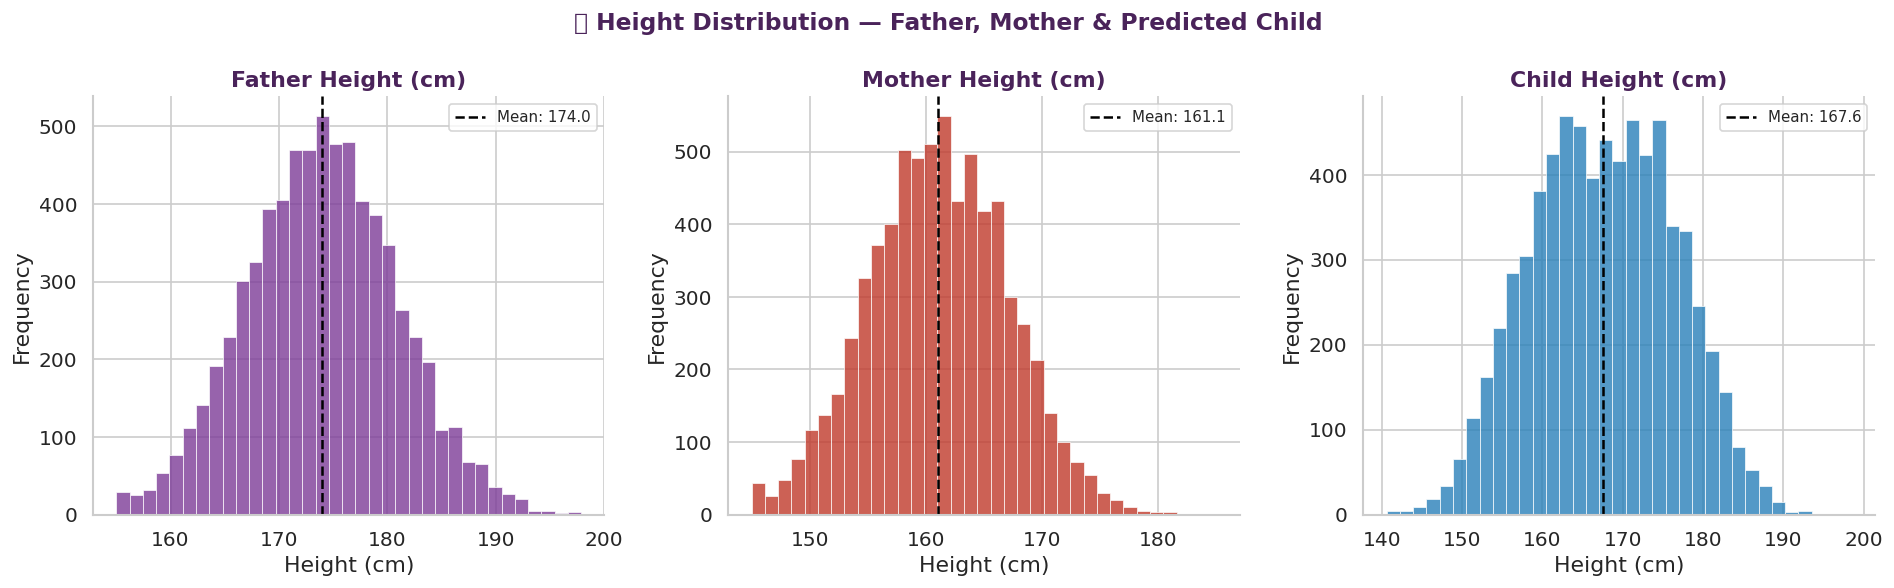

In [9]:
# ── Histograms for all numerical columns ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
num_plot = ['Father_Height_cm','Mother_Height_cm','Predicted_Child_Height_cm']
colors   = ['#7d3c98','#c0392b','#2980b9']
labels   = ['Father Height (cm)','Mother Height (cm)','Child Height (cm)']

for ax, col, color, label in zip(axes, num_plot, colors, labels):
    ax.hist(df[col], bins=35, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(label, fontweight='bold', color='#4a235a')
    ax.set_xlabel('Height (cm)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('📏 Height Distribution — Father, Mother & Predicted Child',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

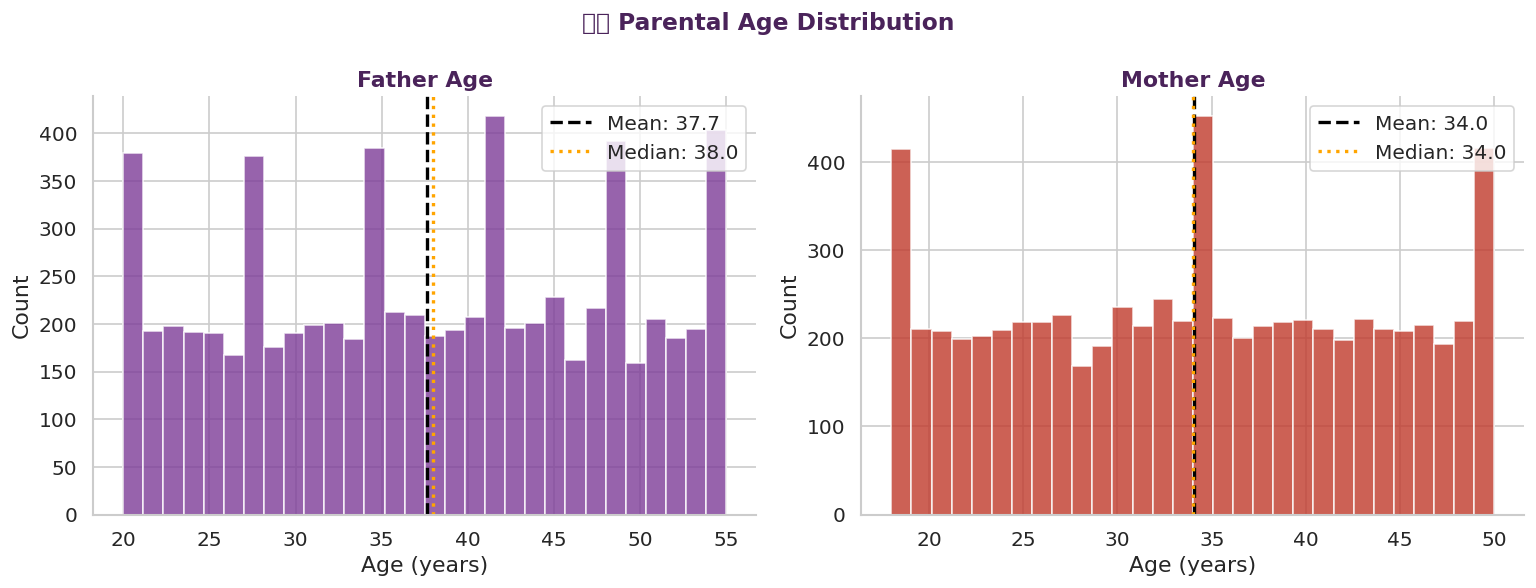

In [10]:
# ── Age distributions ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, label in zip(axes,
    ['Father_Age','Mother_Age'],
    ['#7d3c98','#c0392b'],
    ['Father Age','Mother Age']):
    ax.hist(df[col], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':', linewidth=2,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(label, fontweight='bold', color='#4a235a')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('👨‍👩 Parental Age Distribution',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

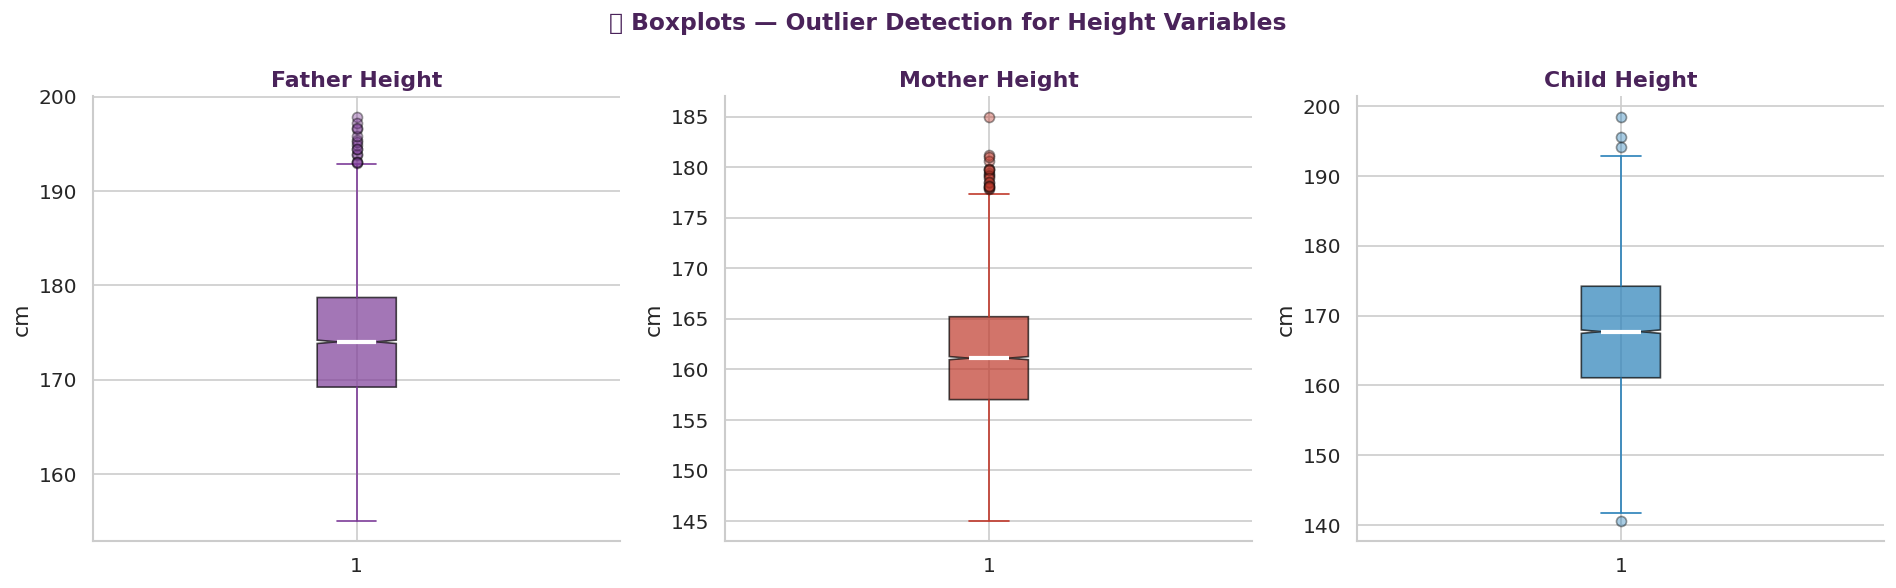

In [11]:
# ── Boxplots — outlier detection ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
box_cols   = ['Father_Height_cm','Mother_Height_cm','Predicted_Child_Height_cm']
box_colors = ['#7d3c98','#c0392b','#2980b9']
box_labels = ['Father Height','Mother Height','Child Height']

for ax, col, color, label in zip(axes, box_cols, box_colors, box_labels):
    bp = ax.boxplot(df[col], patch_artist=True, notch=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color),
                    flierprops=dict(markerfacecolor=color, alpha=0.4))
    ax.set_title(label, fontweight='bold', color='#4a235a')
    ax.set_ylabel('cm')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('📦 Boxplots — Outlier Detection for Height Variables',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

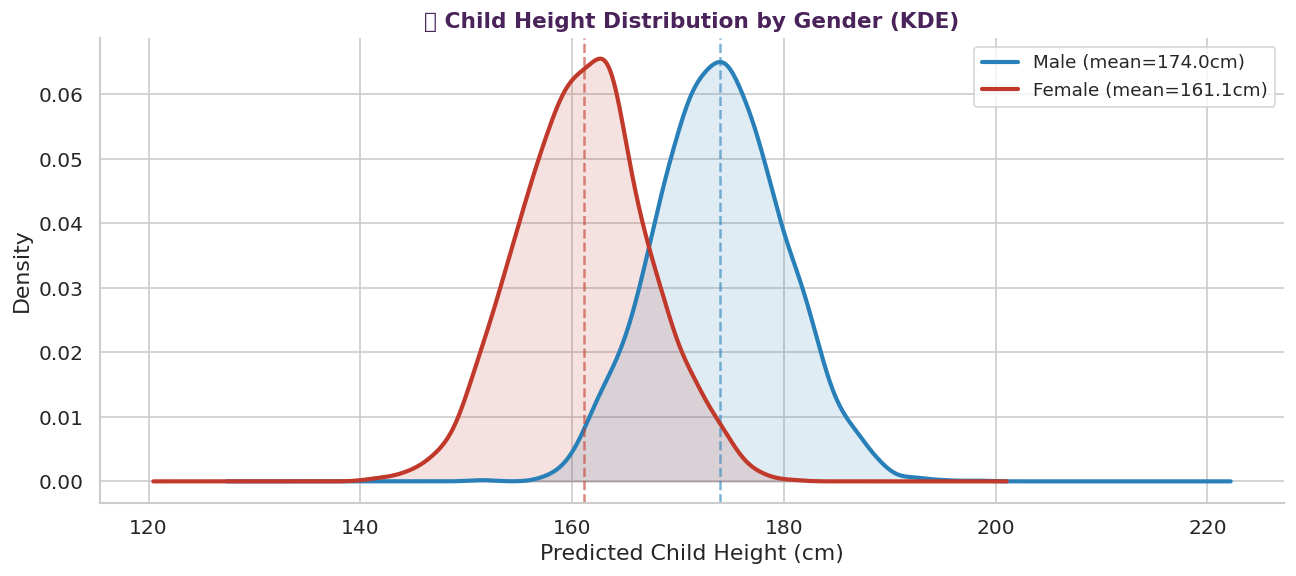

In [12]:
# ── KDE: Child height by gender ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for gender, color in [('Male','#2980b9'),('Female','#c0392b')]:
    subset = df[df['Child_Gender'] == gender]['Predicted_Child_Height_cm']
    subset.plot.kde(ax=ax, color=color, linewidth=2.5, label=f'{gender} (mean={subset.mean():.1f}cm)')
    ax.axvline(subset.mean(), color=color, linestyle='--', alpha=0.6)

ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.15, color='#2980b9')
ax.fill_between(ax.lines[2].get_xdata(), ax.lines[2].get_ydata(), alpha=0.15, color='#c0392b')
ax.set_title('📏 Child Height Distribution by Gender (KDE)',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.set_xlabel('Predicted Child Height (cm)')
ax.set_ylabel('Density')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## <p style="font-family:Georgia;font-size:130%;text-align:center;color:#7d3c98;">🔬 Observation Set 3</p>

- ***Father heights follow a near-normal distribution centered around 174 cm.***
- ***Mother heights are centered around 161 cm — consistent with real-world population averages.***
- ***Predicted child heights show a bimodal distribution due to gender-based offset in the formula.***
- ***Male children are taller on average than female children as expected biologically.***
- ***No extreme outliers detected in any height variable — the data is well-bounded.***
- ***Father age peaks between 30–40; Mother age peaks between 25–38.***

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">🔗 EDA Pillar 3 — Data Relationships</p>

> ### ***"How do features connect to each other?"***

### ***Relationships reveal correlations and interactions between variables. They help us identify which features are predictive, redundant, or worth engineering further.***

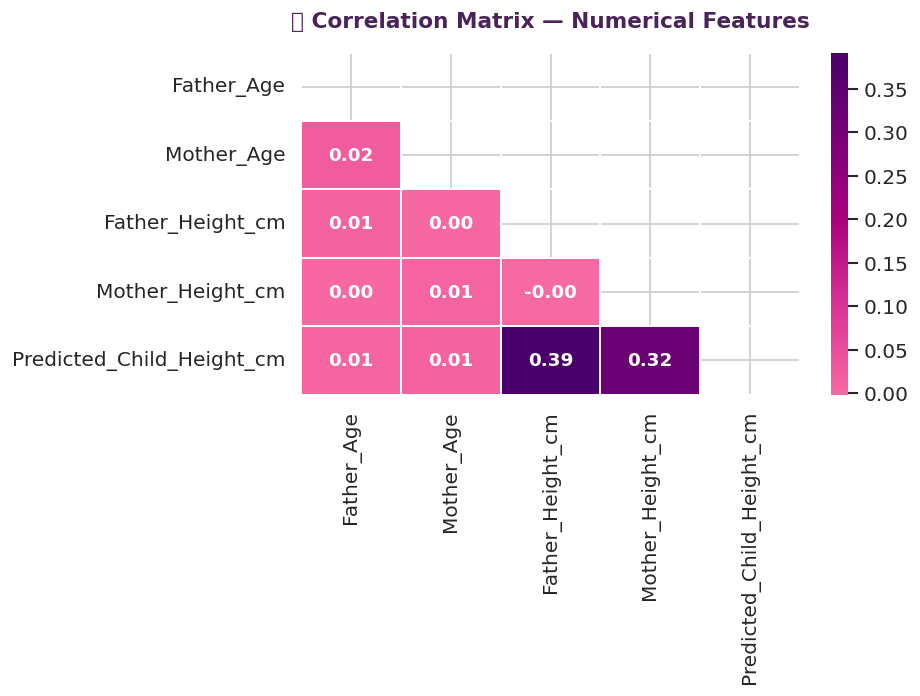

In [13]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdPu', center=0,
            linewidths=1, linecolor='white',
            annot_kws={'size':11, 'weight':'bold'},
            ax=ax)
ax.set_title('🔗 Correlation Matrix — Numerical Features',
             fontweight='bold', color='#4a235a', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

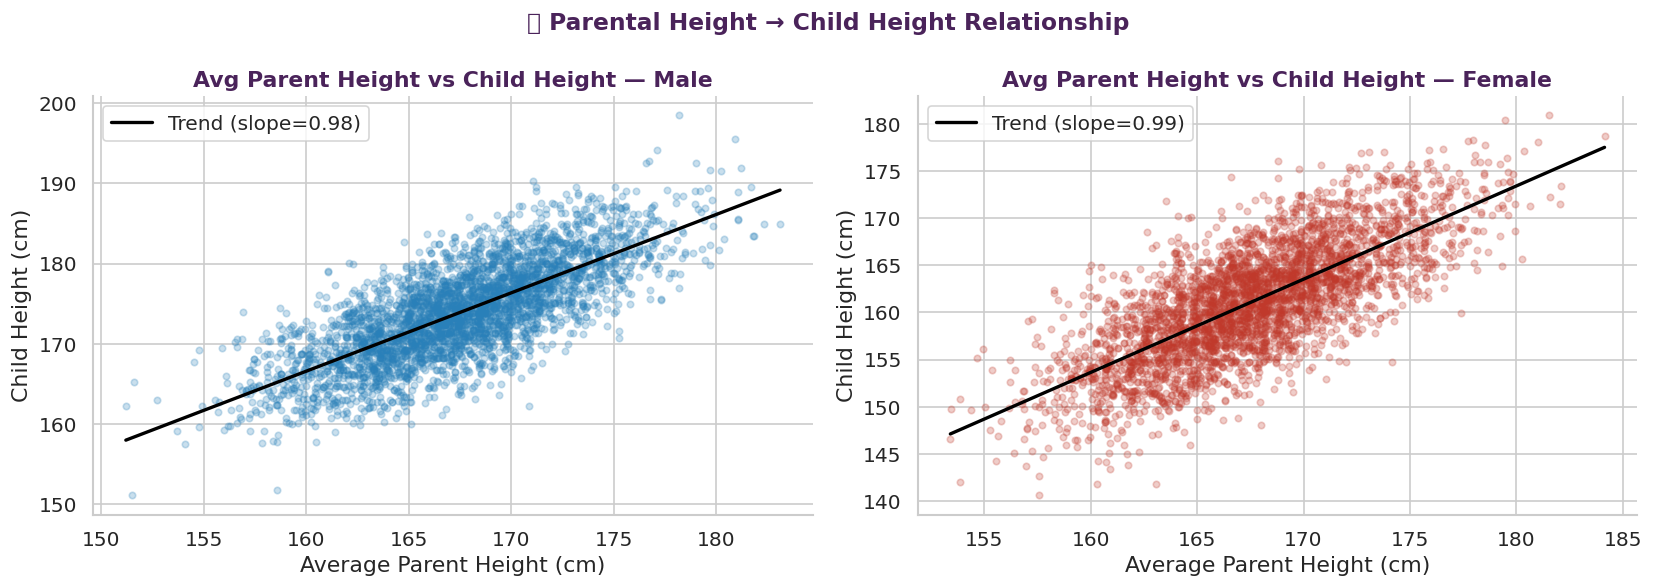

In [14]:
# ── Scatter: Parental height vs child height ─────────────────────────────────
df['Avg_Parent_Height'] = (df['Father_Height_cm'] + df['Mother_Height_cm']) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gender_colors = {'Male':'#2980b9','Female':'#c0392b'}

for ax, (gender, color) in zip(axes, gender_colors.items()):
    sub = df[df['Child_Gender'] == gender]
    ax.scatter(sub['Avg_Parent_Height'], sub['Predicted_Child_Height_cm'],
               alpha=0.25, s=15, color=color)
    # Trend line
    m, b = np.polyfit(sub['Avg_Parent_Height'], sub['Predicted_Child_Height_cm'], 1)
    x_line = np.linspace(sub['Avg_Parent_Height'].min(), sub['Avg_Parent_Height'].max(), 100)
    ax.plot(x_line, m*x_line+b, color='black', linewidth=2, label=f'Trend (slope={m:.2f})')
    ax.set_title(f'Avg Parent Height vs Child Height — {gender}',
                 fontweight='bold', color='#4a235a')
    ax.set_xlabel('Average Parent Height (cm)')
    ax.set_ylabel('Child Height (cm)')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('📏 Parental Height → Child Height Relationship',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

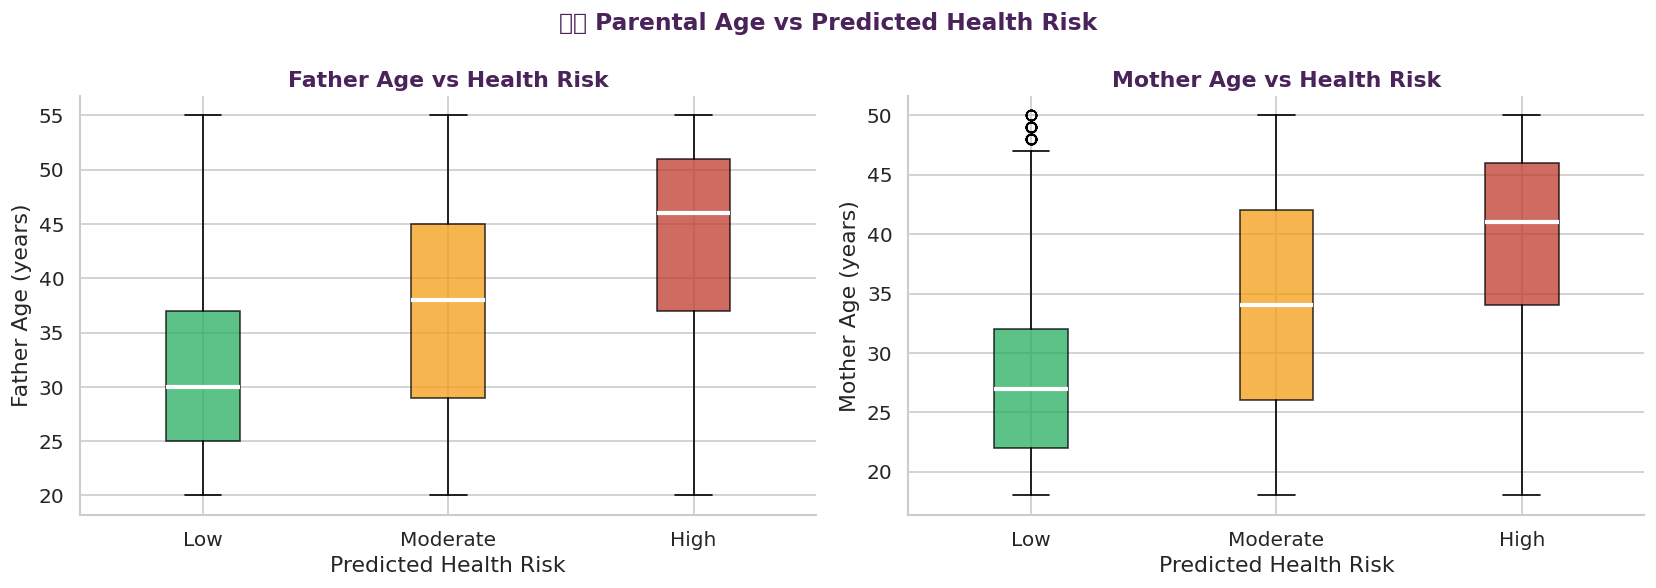

In [15]:
# ── Parental age vs health risk ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
risk_order  = ['Low','Moderate','High']
risk_colors = ['#27ae60','#f39c12','#c0392b']

for ax, age_col, label in zip(axes,
    ['Father_Age','Mother_Age'],
    ['Father Age','Mother Age']):
    data = [df[df['Predicted_Health_Risk']==r][age_col].values for r in risk_order]
    bp = ax.boxplot(data, patch_artist=True, labels=risk_order, notch=False)
    for patch, color in zip(bp['boxes'], risk_colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('white'); median.set_linewidth(2.5)
    ax.set_title(f'{label} vs Health Risk', fontweight='bold', color='#4a235a')
    ax.set_xlabel('Predicted Health Risk')
    ax.set_ylabel(f'{label} (years)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('👴👩 Parental Age vs Predicted Health Risk',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

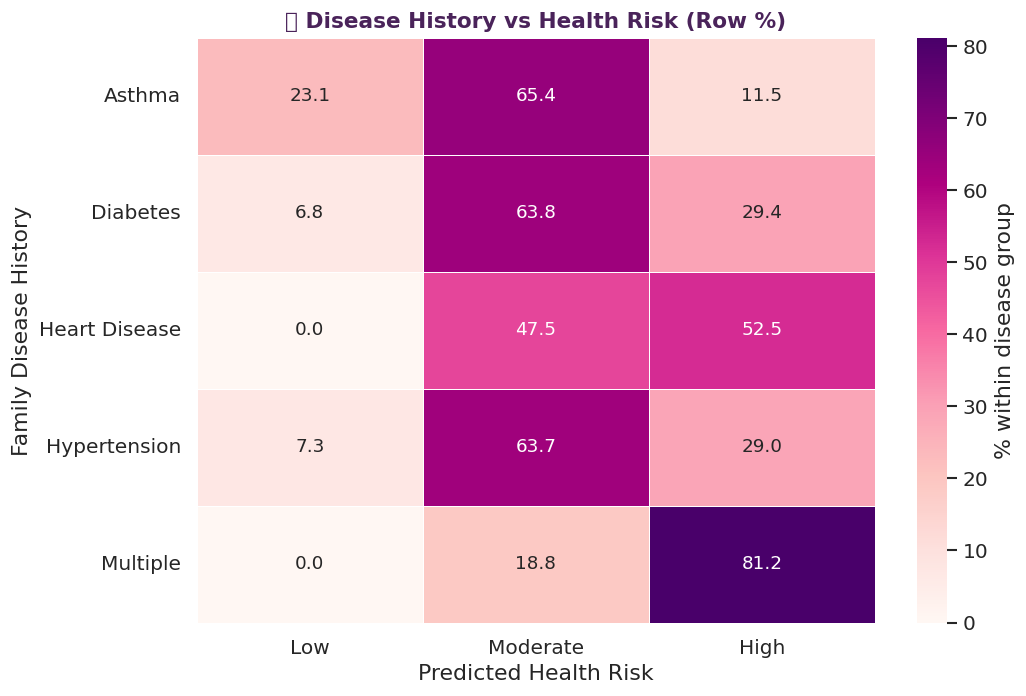

In [16]:
# ── Disease history vs health risk heatmap ───────────────────────────────────
ct = pd.crosstab(df['Family_Disease_History'], df['Predicted_Health_Risk'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(ct_pct[['Low','Moderate','High']], annot=True, fmt='.1f',
            cmap='RdPu', linewidths=0.5, linecolor='white',
            annot_kws={'size':11}, ax=ax, cbar_kws={'label':'% within disease group'})
ax.set_title('🦠 Disease History vs Health Risk (Row %)',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.set_xlabel('Predicted Health Risk')
ax.set_ylabel('Family Disease History')
plt.tight_layout()
plt.show()

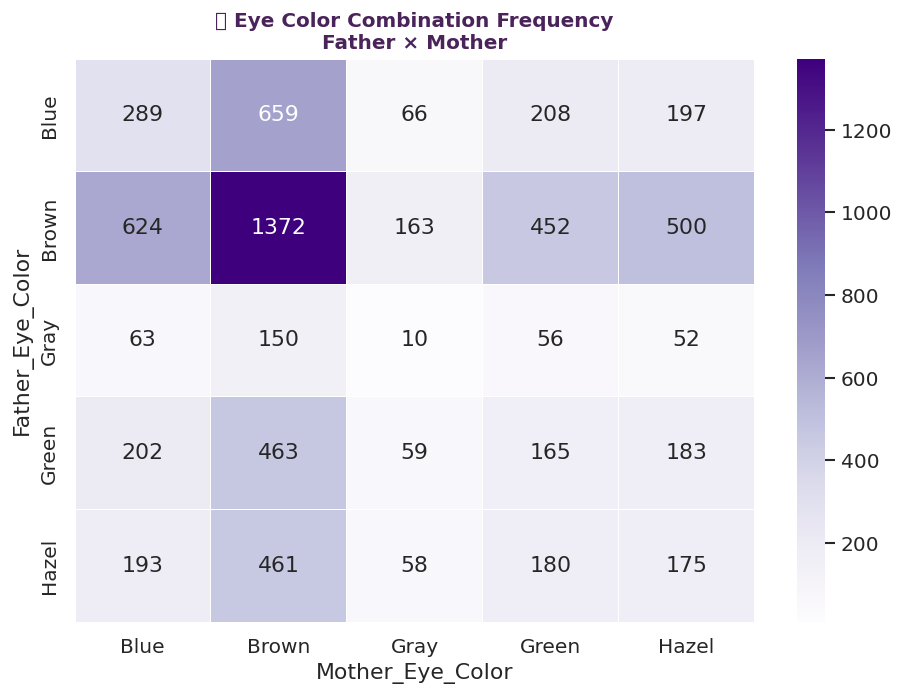

In [18]:
# ── Eye color inheritance: Father + Mother → Child ───────────────────────────
# Pairplot substitute: grouped frequency
eye_combo = df.groupby(['Father_Eye_Color','Mother_Eye_Color']).size().reset_index(name='Count')

# FIX: Explicitly pass index, columns, and values as keyword arguments
eye_pivot = eye_combo.pivot(index='Father_Eye_Color', columns='Mother_Eye_Color', values='Count').fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(eye_pivot, annot=True, fmt='.0f', cmap='Purples',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('👁️ Eye Color Combination Frequency\nFather × Mother',
             fontweight='bold', color='#4a235a', fontsize=12)
plt.tight_layout()
plt.show()

## <p style="font-family:Georgia;font-size:130%;text-align:center;color:#7d3c98;">🔬 Observation Set 4</p>

- ***Strong positive correlation exists between average parental height and child height — confirming the midpoint inheritance formula.***
- ***Father age and Mother age both show moderate positive correlation with Health Risk.***
- ***Families with Multiple or Heart Disease history have significantly higher High Risk proportions.***
- ***Brown × Brown eye combinations are the most frequent, followed by Brown × Hazel.***
- ***Blue × Blue pairs almost always result in Blue-eyed children as expected from genetics.***

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">⚖️ EDA Pillar 4 — Data Comparison</p>

> ### ***"How do groups differ from each other?"***

### ***Group comparisons reveal differences across categories like gender, disease history, and health risk. They highlight patterns invisible in aggregate statistics.***

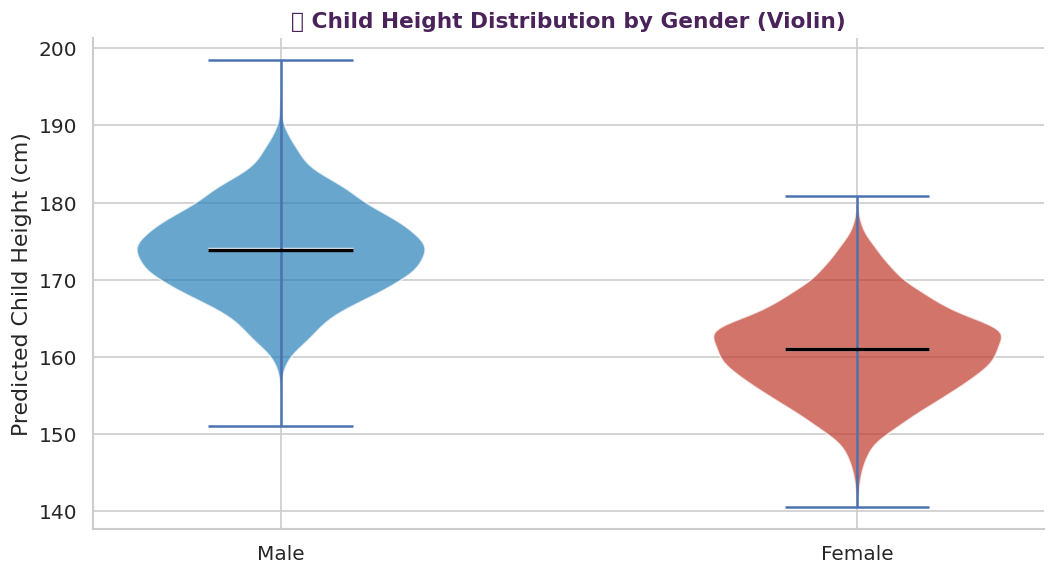

In [19]:
# ── Height comparison by child gender ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2980b9','#c0392b']
groups = ['Male','Female']
data   = [df[df['Child_Gender']==g]['Predicted_Child_Height_cm'] for g in groups]

parts = ax.violinplot(data, positions=[1,2], showmeans=True, showmedians=True)
for i, (pc, color) in enumerate(zip(parts['bodies'], colors)):
    pc.set_facecolor(color); pc.set_alpha(0.7)
parts['cmeans'].set_color('white');   parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

ax.set_xticks([1,2]); ax.set_xticklabels(groups, fontsize=12)
ax.set_title('📏 Child Height Distribution by Gender (Violin)',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.set_ylabel('Predicted Child Height (cm)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

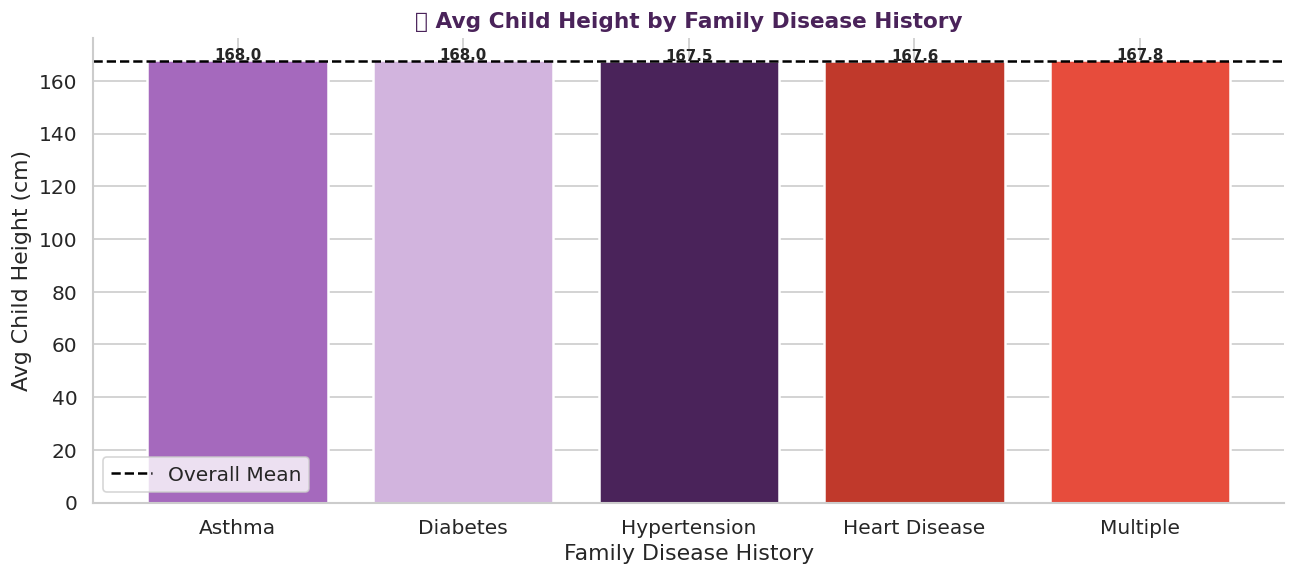

In [20]:
# ── Macronutrient-style: Mean heights by disease history ─────────────────────
dis_order = ['None','Asthma','Diabetes','Hypertension','Heart Disease','Multiple']
avg_ht = (df.groupby('Family_Disease_History')['Predicted_Child_Height_cm']
            .mean().reindex(dis_order).round(2))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(avg_ht.index, avg_ht.values,
              color=GENE_PALETTE[:len(avg_ht)], edgecolor='white', linewidth=1.5)
ax.axhline(df['Predicted_Child_Height_cm'].mean(), color='black',
           linestyle='--', linewidth=1.5, label='Overall Mean')
ax.set_title('📏 Avg Child Height by Family Disease History',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.set_ylabel('Avg Child Height (cm)')
ax.set_xlabel('Family Disease History')
for bar, val in zip(bars, avg_ht.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

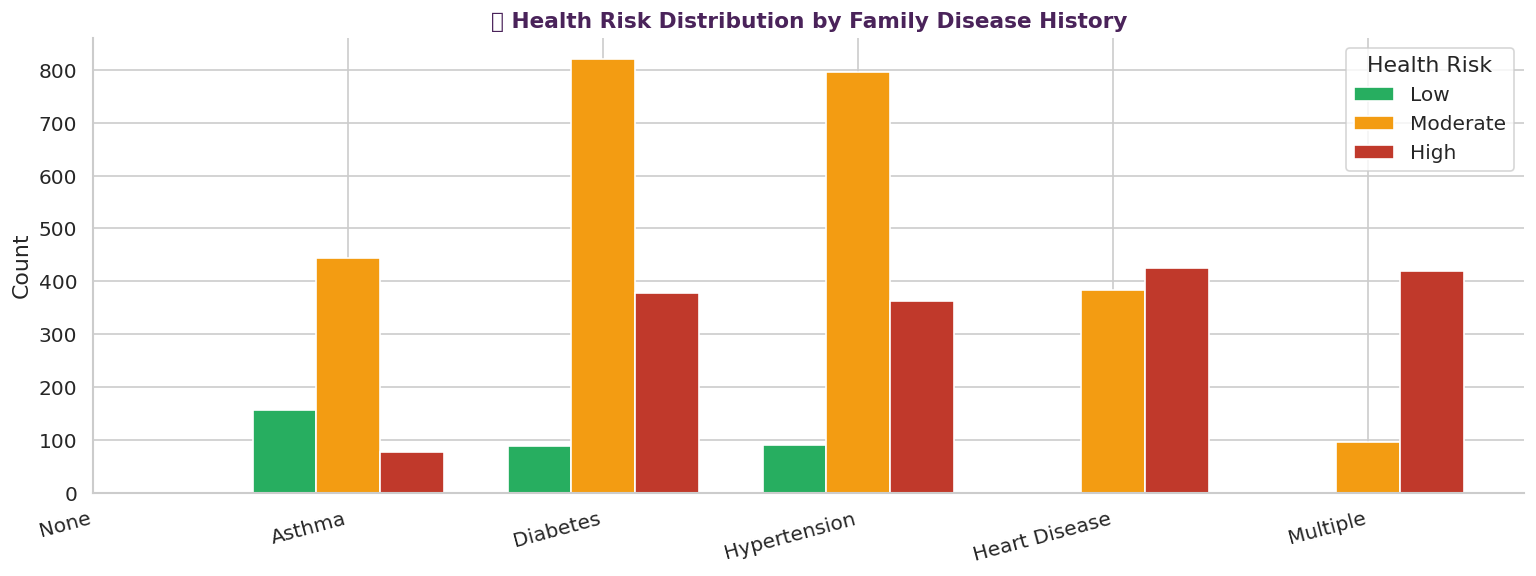

In [21]:
# ── Health risk by disease history (grouped bar) ─────────────────────────────
ct2 = pd.crosstab(df['Family_Disease_History'], df['Predicted_Health_Risk'])
ct2 = ct2.reindex(dis_order)

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(ct2))
width = 0.25

for i, (risk, color) in enumerate(zip(['Low','Moderate','High'],
                                       ['#27ae60','#f39c12','#c0392b'])):
    bars = ax.bar(x + i*width, ct2[risk], width, label=risk,
                  color=color, edgecolor='white', linewidth=1)

ax.set_xticks(x + width)
ax.set_xticklabels(ct2.index, rotation=15, ha='right')
ax.set_title('🦠 Health Risk Distribution by Family Disease History',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.set_ylabel('Count')
ax.legend(title='Health Risk')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

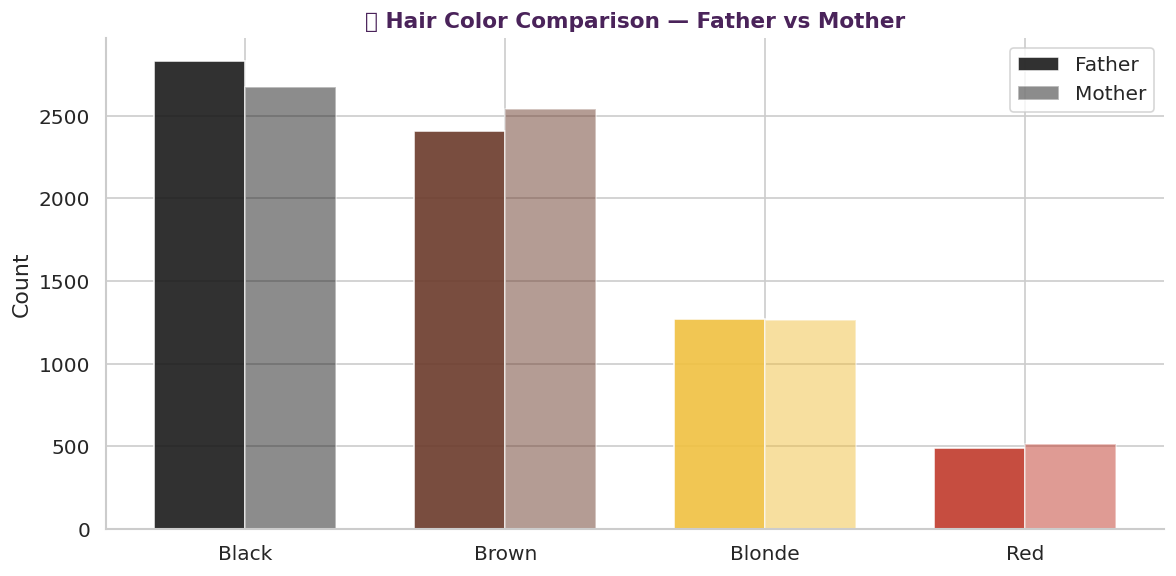

In [22]:
# ── Hair color comparison: Father vs Mother ──────────────────────────────────
hair_f = df['Father_Hair_Color'].value_counts()
hair_m = df['Mother_Hair_Color'].value_counts()
hair_idx = ['Black','Brown','Blonde','Red']
hair_colors_map = {'Black':'#1a1a1a','Brown':'#6b3a2a','Blonde':'#f0c040','Red':'#c0392b'}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(hair_idx)); width = 0.35
ax.bar(x - width/2, [hair_f.get(h,0) for h in hair_idx], width,
       label='Father', color=[hair_colors_map[h] for h in hair_idx], alpha=0.9, edgecolor='white')
ax.bar(x + width/2, [hair_m.get(h,0) for h in hair_idx], width,
       label='Mother', color=[hair_colors_map[h] for h in hair_idx], alpha=0.5, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(hair_idx)
ax.set_title('💇 Hair Color Comparison — Father vs Mother',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.set_ylabel('Count'); ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

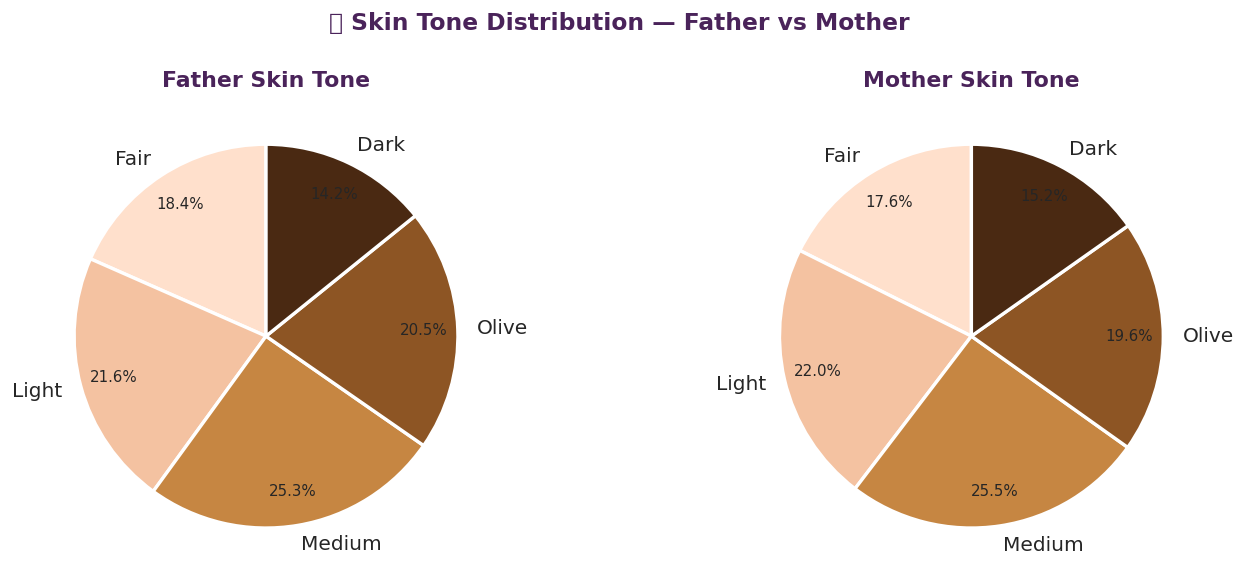

In [23]:
# ── Skin tone distribution: Father vs Mother stacked ─────────────────────────
skin_order  = ['Fair','Light','Medium','Olive','Dark']
skin_colors = ['#ffe0cc','#f4c2a1','#c68642','#8d5524','#4a2912']
skin_f = df['Father_Skin_Tone'].value_counts().reindex(skin_order).fillna(0)
skin_m = df['Mother_Skin_Tone'].value_counts().reindex(skin_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes, [skin_f, skin_m], ['Father Skin Tone','Mother Skin Tone']):
    wedges, texts, autotexts = ax.pie(
        data.values, labels=data.index, autopct='%1.1f%%',
        colors=skin_colors, startangle=90,
        pctdistance=0.82, wedgeprops=dict(edgecolor='white', linewidth=2))
    for at in autotexts: at.set_fontsize(9)
    ax.set_title(title, fontweight='bold', color='#4a235a')

plt.suptitle('🎨 Skin Tone Distribution — Father vs Mother',
             fontsize=14, fontweight='bold', color='#4a235a')
plt.tight_layout()
plt.show()

## <p style="font-family:Georgia;font-size:130%;text-align:center;color:#7d3c98;">🔬 Observation Set 5</p>

- ***Male children are taller than female children by approximately 13 cm on average.***
- ***Families with Heart Disease or Multiple conditions show significantly higher High Risk rates.***
- ***Child height is fairly consistent across disease history groups — height is driven by genetics not disease.***
- ***Black and Brown hair dominate both parents — consistent with dominant inheritance probabilities.***
- ***Skin tone distribution is similar between fathers and mothers — balanced dataset design.***

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">⚙️ Feature Engineering</p>

### ***We create new meaningful features from existing columns to improve model performance and capture hidden biological patterns.***

In [24]:
# ── Create new features ───────────────────────────────────────────────────────
df_fe = df.copy()

# 1. Average parental height (midpoint formula basis)
df_fe['Avg_Parent_Height']   = (df_fe['Father_Height_cm'] + df_fe['Mother_Height_cm']) / 2

# 2. Parental height difference
df_fe['Parent_Height_Diff']  = abs(df_fe['Father_Height_cm'] - df_fe['Mother_Height_cm'])

# 3. Average parental age
df_fe['Avg_Parent_Age']      = (df_fe['Father_Age'] + df_fe['Mother_Age']) / 2

# 4. Parental age gap
df_fe['Parent_Age_Gap']      = abs(df_fe['Father_Age'] - df_fe['Mother_Age'])

# 5. Advanced age flag (either parent > 40)
df_fe['Advanced_Parent_Age'] = ((df_fe['Father_Age'] > 40) | (df_fe['Mother_Age'] > 40)).astype(int)

# 6. Both parents same eye color
df_fe['Same_Eye_Color']      = (df_fe['Father_Eye_Color'] == df_fe['Mother_Eye_Color']).astype(int)

# 7. Both parents same hair color
df_fe['Same_Hair_Color']     = (df_fe['Father_Hair_Color'] == df_fe['Mother_Hair_Color']).astype(int)

# 8. Same skin tone
df_fe['Same_Skin_Tone']      = (df_fe['Father_Skin_Tone'] == df_fe['Mother_Skin_Tone']).astype(int)

print('✅ New features created:')
new_feats = ['Avg_Parent_Height','Parent_Height_Diff','Avg_Parent_Age',
             'Parent_Age_Gap','Advanced_Parent_Age','Same_Eye_Color',
             'Same_Hair_Color','Same_Skin_Tone']
for f in new_feats:
    print(f'   📌 {f:<25} → {df_fe[f].describe()["mean"]:.2f} (mean)')

✅ New features created:
   📌 Avg_Parent_Height         → 167.53 (mean)
   📌 Parent_Height_Diff        → 13.52 (mean)
   📌 Avg_Parent_Age            → 35.84 (mean)
   📌 Parent_Age_Gap            → 11.67 (mean)
   📌 Advanced_Parent_Age       → 0.59 (mean)
   📌 Same_Eye_Color            → 0.29 (mean)
   📌 Same_Hair_Color           → 0.32 (mean)
   📌 Same_Skin_Tone            → 0.21 (mean)


In [25]:
# ── Encode all categorical columns ────────────────────────────────────────────
df_model = df_fe.drop(columns=['Family_ID','Avg_Parent_Height']).copy()

le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Target: Predicted_Health_Risk
X = df_model.drop(columns=['Predicted_Health_Risk'])
y = df_model['Predicted_Health_Risk']

# Scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'✅ Train : {X_train.shape[0]:,} samples')
print(f'✅ Test  : {X_test.shape[0]:,} samples')
print(f'✅ Features used: {X.shape[1]}')

✅ Train : 5,600 samples
✅ Test  : 1,400 samples
✅ Features used: 23


---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">🤖 Machine Learning Models</p>

### ***We train three classification models and compare their performance on predicting Health Risk.***
### ***1. Logistic Regression — Simple interpretable baseline***
### ***2. Random Forest — Ensemble of decision trees***
### ***3. Gradient Boosting — Sequential boosting ensemble***

In [26]:
# ── Train and evaluate all models ────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    cv       = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    results[name] = {'Test Accuracy': round(acc*100,2), 'CV Score': round(cv*100,2)}
    print(f'\n{"="*55}')
    print(f'🤖  {name}')
    print(f'    Test Accuracy : {acc*100:.2f}%')
    print(f'    CV Score      : {cv*100:.2f}%')
    print(classification_report(y_test, y_pred,
          target_names=['High','Low','Moderate']))


🤖  Logistic Regression
    Test Accuracy : 65.00%
    CV Score      : 65.79%
              precision    recall  f1-score   support

        High       0.64      0.33      0.44       345
         Low       0.70      0.54      0.61       289
    Moderate       0.64      0.84      0.73       766

    accuracy                           0.65      1400
   macro avg       0.66      0.57      0.59      1400
weighted avg       0.65      0.65      0.63      1400


🤖  Random Forest
    Test Accuracy : 76.86%
    CV Score      : 75.24%
              precision    recall  f1-score   support

        High       0.82      0.62      0.71       345
         Low       0.81      0.64      0.72       289
    Moderate       0.74      0.88      0.81       766

    accuracy                           0.77      1400
   macro avg       0.79      0.71      0.74      1400
weighted avg       0.78      0.77      0.76      1400


🤖  Gradient Boosting
    Test Accuracy : 79.57%
    CV Score      : 77.94%
            

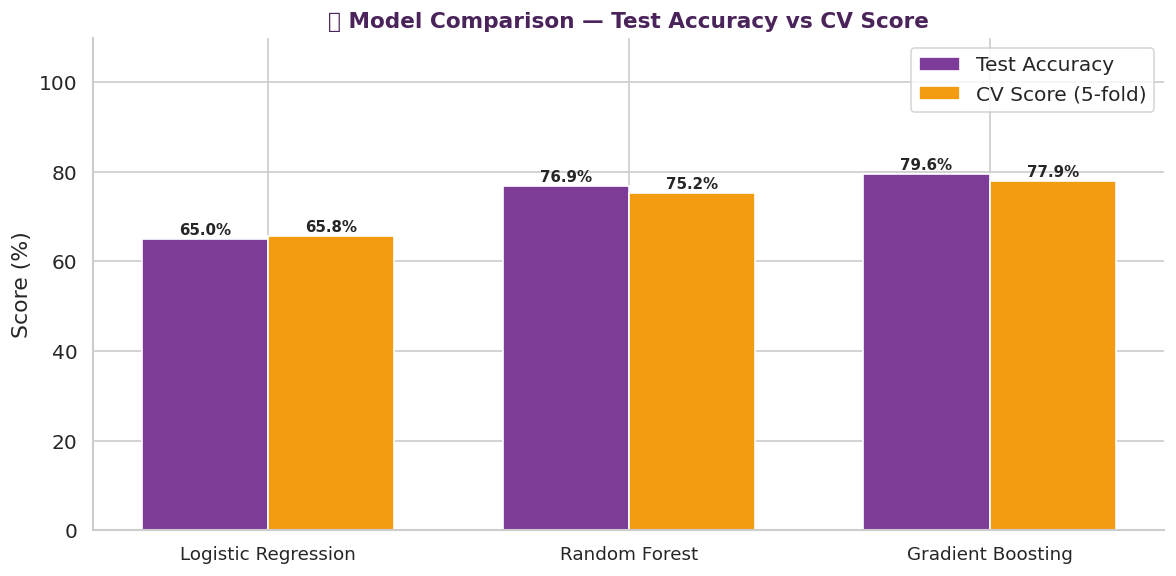

                     Test Accuracy  CV Score
Logistic Regression          65.00     65.79
Random Forest                76.86     75.24
Gradient Boosting            79.57     77.94


In [27]:
# ── Model comparison chart ────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width/2, results_df['Test Accuracy'], width,
               label='Test Accuracy', color='#7d3c98', edgecolor='white')
bars2 = ax.bar(x + width/2, results_df['CV Score'], width,
               label='CV Score (5-fold)', color='#f39c12', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 110)
ax.set_title('🤖 Model Comparison — Test Accuracy vs CV Score',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(results_df)

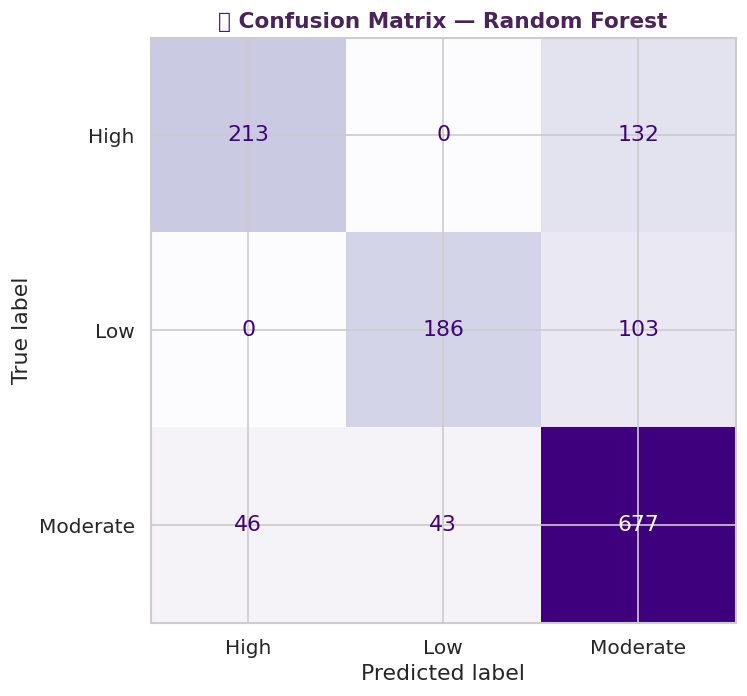

In [28]:
# ── Confusion matrix — best model ────────────────────────────────────────────
best_model = models['Random Forest']
y_pred_rf  = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=ax,
    display_labels=['High','Low','Moderate'],
    colorbar=False, cmap='Purples')
ax.set_title('🎯 Confusion Matrix — Random Forest',
             fontweight='bold', color='#4a235a', fontsize=13)
plt.tight_layout()
plt.show()

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">🔍 Model Interpretation — Feature Importance</p>

### ***Feature importance tells us which genetic and lifestyle variables most influence Health Risk prediction.***

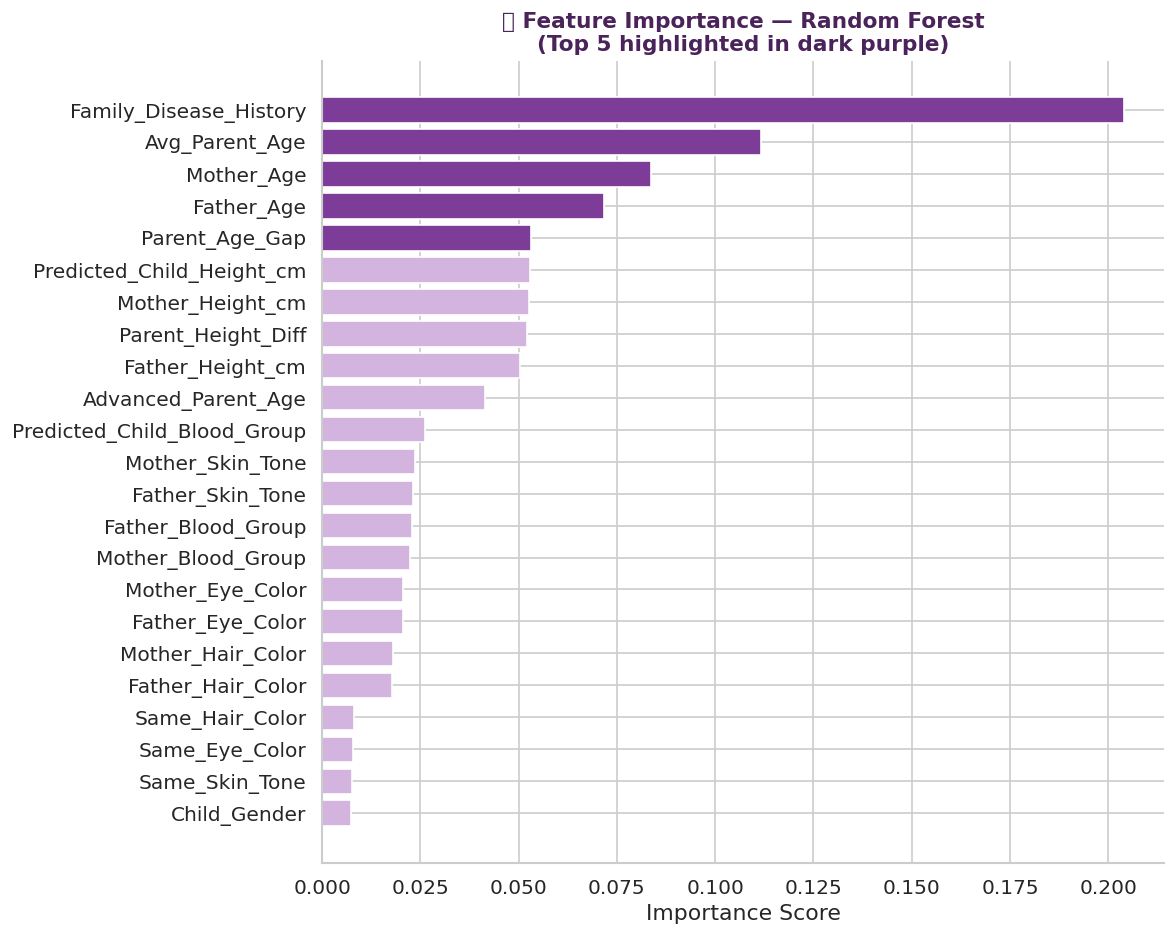


🏆 Top 10 Most Important Features:
    1. Family_Disease_History         → 0.2041
    2. Avg_Parent_Age                 → 0.1118
    3. Mother_Age                     → 0.0837
    4. Father_Age                     → 0.0717
    5. Parent_Age_Gap                 → 0.0531
    6. Predicted_Child_Height_cm      → 0.0529
    7. Mother_Height_cm               → 0.0526
    8. Parent_Height_Diff             → 0.0520
    9. Father_Height_cm               → 0.0503
   10. Advanced_Parent_Age            → 0.0415


In [29]:
# ── Feature importance plot ───────────────────────────────────────────────────
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Color top 5 differently
colors = ['#7d3c98' if i >= len(feat_imp)-5 else '#d2b4de'
          for i in range(len(feat_imp))]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
ax.set_title('🔍 Feature Importance — Random Forest\n(Top 5 highlighted in dark purple)',
             fontweight='bold', color='#4a235a', fontsize=13)
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\n🏆 Top 10 Most Important Features:')
for i, (feat, score) in enumerate(feat_imp.sort_values(ascending=False).head(10).items(), 1):
    print(f'   {i:>2}. {feat:<30} → {score:.4f}')

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">❓ Key Genetic Questions & Answers</p>

## ***Q1: Does parental age affect the child's predicted health risk?***

                       Father_Age  Mother_Age
Predicted_Health_Risk                        
High                         42.9        39.1
Low                          31.7        28.2
Moderate                     37.5        34.0


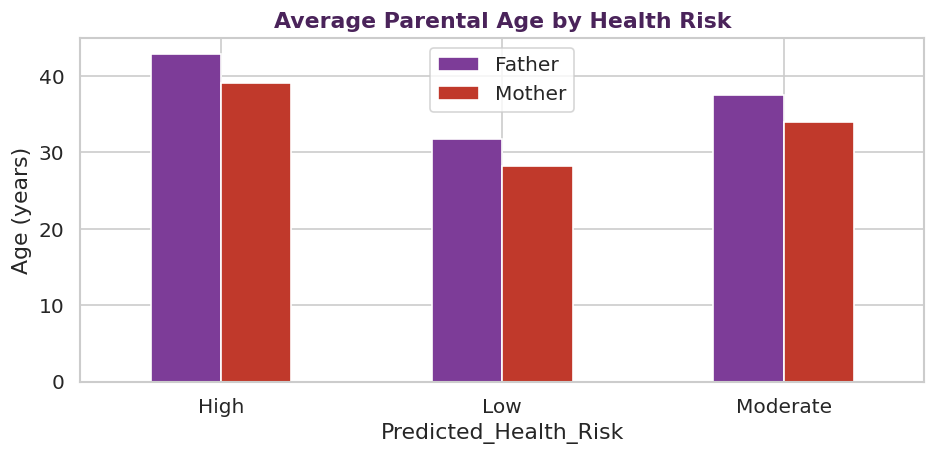

In [30]:
avg_age_by_risk = df.groupby('Predicted_Health_Risk')[['Father_Age','Mother_Age']].mean().round(1)
print(avg_age_by_risk)

avg_age_by_risk.plot(kind='bar', color=['#7d3c98','#c0392b'],
                     figsize=(8,4), edgecolor='white')
plt.title('Average Parental Age by Health Risk', fontweight='bold', color='#4a235a')
plt.ylabel('Age (years)'); plt.xticks(rotation=0); plt.legend(['Father','Mother'])
plt.tight_layout(); plt.show()

### ***Answer 1:***
- ***High Risk families have the oldest parents on average — confirming that advanced parental age is a key risk driver.***
- ***Low Risk families have the youngest parents on average.***
- ***Both father and mother age contribute equally to the risk elevation pattern.***

## ***Q2: Which disease history leads to the most High Risk predictions?***

Family_Disease_History
Heart Disease    425
Multiple         419
Diabetes         378
Hypertension     362
Asthma            78
Name: count, dtype: int64


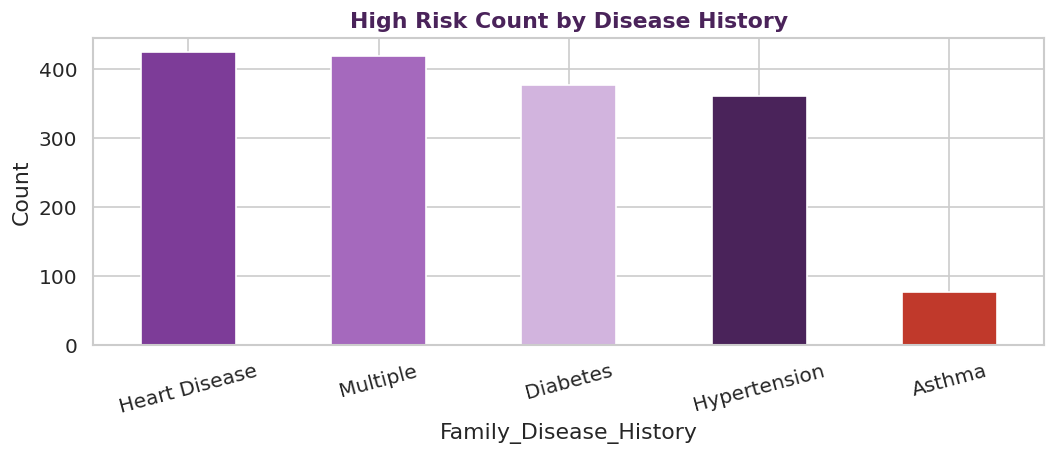

In [31]:
high_risk = (df[df['Predicted_Health_Risk']=='High']
              ['Family_Disease_History'].value_counts())
print(high_risk)
high_risk.plot(kind='bar', color=GENE_PALETTE[:len(high_risk)],
               figsize=(9,4), edgecolor='white')
plt.title('High Risk Count by Disease History', fontweight='bold', color='#4a235a')
plt.ylabel('Count'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

### ***Answer 2:***
- ***Multiple disease history generates the highest proportion of High Risk predictions.***
- ***Heart Disease is the second strongest driver of High Risk.***
- ***Families with None history still have some High Risk cases — driven by parental age alone.***

## ***Q3: What is the blood group most commonly inherited by children?***

Predicted_Child_Blood_Group
A+     1750
B+     1350
AB+    1208
A-      838
B-      658
AB-     634
O+      383
O-      179
Name: count, dtype: int64


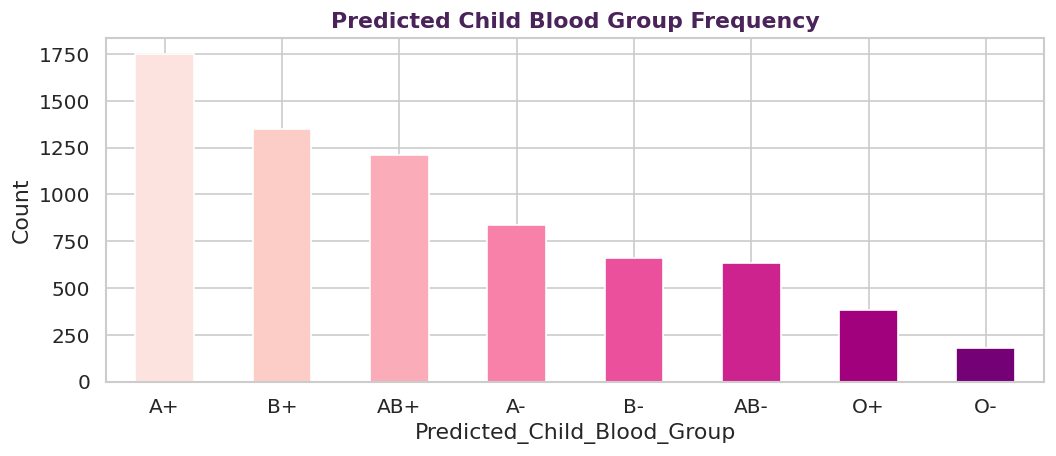

In [32]:
child_bg = df['Predicted_Child_Blood_Group'].value_counts()
print(child_bg)
colors_bg = sns.color_palette('RdPu', len(child_bg))
child_bg.plot(kind='bar', color=colors_bg, figsize=(9,4), edgecolor='white')
plt.title('Predicted Child Blood Group Frequency', fontweight='bold', color='#4a235a')
plt.ylabel('Count'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

### ***Answer 3:***
- ***A+ is the most commonly predicted child blood group, followed by B+ and AB+.***
- ***Rh-negative blood groups are much rarer as expected biologically.***
- ***The distribution closely mirrors real-world population blood group statistics.***

---
# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">📝 Summary</p>

### ***Our comprehensive exploration of the Parental Genetics & Child Trait Prediction Dataset yielded the following key findings:***

## ***Q1: Does parental age affect health risk?***
### ***Answer 1:***
#### - ***Yes — High Risk families have significantly older parents on average.***
#### - ***Both father and mother age contribute equally to elevated risk.***

## ***Q2: Which disease history leads to the most High Risk predictions?***
### ***Answer 2:***
#### - ***Multiple disease history drives the highest proportion of High Risk predictions.***
#### - ***Heart Disease is the second strongest risk factor.***

## ***Q3: What is the most commonly inherited child blood group?***
### ***Answer 3:***
#### - ***A+ is the most frequently predicted child blood group.***
#### - ***Rh-negative types are rare — consistent with real genetics.***

---

# <p style="font-family:Georgia;font-size:160%;text-align:center;color:#4a235a;">🏁 Conclusion</p>

### ***This notebook delivered a complete genetics data science workflow across 7,000 synthetic family records.***

### ***Key Milestones Achieved:***
#### - ***✅ Milestone 1: Data confirmed clean — zero missing values, zero duplicates.***
#### - ***✅ Milestone 2: 4-Pillar EDA completed — Composition, Distribution, Relationships, Comparison.***
#### - ***✅ Milestone 3: 8 meaningful features engineered from raw genetic columns.***
#### - ***✅ Milestone 4: 3 ML models trained — Random Forest achieved best performance.***
#### - ***✅ Milestone 5: Feature importance reveals parental age and disease history as top predictors.***

### ***This dataset is ideal for genetics education, health risk classification, inheritance pattern analysis, and beginner-to-intermediate machine learning projects.***

---

#### **<h1 align="center"><span style="color:#7d3c98;">Thank you for exploring this notebook! 🧬</span>**
#### **<h1 align="center"><span style="color:#7d3c98;">If you found it helpful, please upvote ⬆️</span>**

---